In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv("cleaned_global_water_consumption.csv")
data


,Country,Year,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (Annual Precipitation in mm),Groundwater Depletion Rate (%),Water Scarcity Level
0,Argentina,2000,481.490000,235.431429,48.550000,20.844286,30.100000,1288.698571,3.255714,Moderate
1,Argentina,2001,455.063000,299.551000,48.465000,26.943000,22.550000,1371.729000,3.120000,Moderate
2,Argentina,2002,482.749231,340.124615,50.375385,29.042308,23.349231,1590.305385,2.733846,Moderate
3,Argentina,2003,452.660000,326.756667,49.086667,30.476000,24.440000,1816.012667,2.708000,Moderate
4,Argentina,2004,634.566000,230.346000,38.670000,36.670000,23.924000,815.998000,1.902000,Moderate
...,...,...,...,...,...,...,...,...,...,...
495,USA,2020,418.097000,292.970000,47.448000,25.266000,27.538000,1510.662000,2.431000,Moderate
496,USA,2021,572.094000,275.978000,46.195000,32.223000,26.720000,754.615000,2.628000,Moderate
497,USA,2022,440.978000,292.039000,54.810000,30.918000,22.638000,2119.898000,2.871000,Moderate
498,USA,2023,566.865000,261.197500,62.945000,25.207500,21.632500,1439.155000,1.597500,Moderate


In [3]:
data["Country"].unique()

array(['Argentina', 'Australia', 'Brazil', 'Canada', 'China', 'France',
       'Germany', 'India', 'Indonesia', 'Italy', 'Japan', 'Mexico',
       'Russia', 'Saudi Arabia', 'South Africa', 'South Korea', 'Spain',
       'Turkey', 'UK', 'USA'], dtype=object)

## EXPLORATORY DATA ANALYSIS

In [4]:
data.head()

,Country,Year,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (Annual Precipitation in mm),Groundwater Depletion Rate (%),Water Scarcity Level
0,Argentina,2000,481.490000,235.431429,48.550000,20.844286,30.100000,1288.698571,3.255714,Moderate
1,Argentina,2001,455.063000,299.551000,48.465000,26.943000,22.550000,1371.729000,3.120000,Moderate
2,Argentina,2002,482.749231,340.124615,50.375385,29.042308,23.349231,1590.305385,2.733846,Moderate
3,Argentina,2003,452.660000,326.756667,49.086667,30.476000,24.440000,1816.012667,2.708000,Moderate
4,Argentina,2004,634.566000,230.346000,38.670000,36.670000,23.924000,815.998000,1.902000,Moderate


In [5]:
data.tail()

,Country,Year,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (Annual Precipitation in mm),Groundwater Depletion Rate (%),Water Scarcity Level
495,USA,2020,418.097,292.9700,47.448,25.2660,27.5380,1510.662,2.4310,Moderate
496,USA,2021,572.094,275.9780,46.195,32.2230,26.7200,754.615,2.6280,Moderate
497,USA,2022,440.978,292.0390,54.810,30.9180,22.6380,2119.898,2.8710,Moderate
498,USA,2023,566.865,261.1975,62.945,25.2075,21.6325,1439.155,1.5975,Moderate
499,USA,2024,249.485,186.3740,51.386,24.7690,27.6770,1771.199,1.6380,High


In [6]:
data.isna().any()

Country                                           False
Year                                              False
Total Water Consumption (Billion Cubic Meters)    False
Per Capita Water Use (Liters per Day)             False
Agricultural Water Use (%)                        False
Industrial Water Use (%)                          False
Household Water Use (%)                           False
Rainfall Impact (Annual Precipitation in mm)      False
Groundwater Depletion Rate (%)                    False
Water Scarcity Level                              False
dtype: bool

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Country                                         500 non-null    object 
 1   Year                                            500 non-null    int64  
 2   Total Water Consumption (Billion Cubic Meters)  500 non-null    float64
 3   Per Capita Water Use (Liters per Day)           500 non-null    float64
 4   Agricultural Water Use (%)                      500 non-null    float64
 5   Industrial Water Use (%)                        500 non-null    float64
 6   Household Water Use (%)                         500 non-null    float64
 7   Rainfall Impact (Annual Precipitation in mm)    500 non-null    float64
 8   Groundwater Depletion Rate (%)                  500 non-null    float64
 9   Water Scarcity Level                       

In [8]:
data.duplicated().any()

np.False_

In [9]:
data.describe()

,Year,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (Annual Precipitation in mm),Groundwater Depletion Rate (%)
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2012.000000,501.224430,276.004782,50.180829,27.792837,24.832515,1544.824300,2.573037
std,7.218324,96.078937,42.669593,5.566886,4.361660,2.956135,292.786579,0.480630
min,2000.000000,129.636667,111.708333,28.905000,13.276667,13.668333,700.230000,1.300000
25%,2006.000000,441.447385,250.225406,46.513611,25.018000,23.015355,1353.734583,2.235000
50%,2012.000000,502.197154,276.430556,50.318482,27.648539,25.071944,1537.537724,2.555778
75%,2018.000000,563.849594,300.221750,54.061964,30.698333,26.720167,1746.402425,2.887202
max,2024.000000,798.418000,404.350000,66.520000,43.583333,34.202000,2533.678000,4.322000


# VISUALISING DATA BY MATPLOTLIB

In [10]:
data1=data.drop(['Country','Year','Total Water Consumption (Billion Cubic Meters)','Per Capita Water Use (Liters per Day)','Agricultural Water Use (%)','Industrial Water Use (%)','Household Water Use (%)','Rainfall Impact (Annual Precipitation in mm)','Groundwater Depletion Rate (%)'],axis=1)
data1

,Water Scarcity Level
0,Moderate
1,Moderate
2,Moderate
3,Moderate
4,Moderate
...,...
495,Moderate
496,Moderate
497,Moderate
498,Moderate


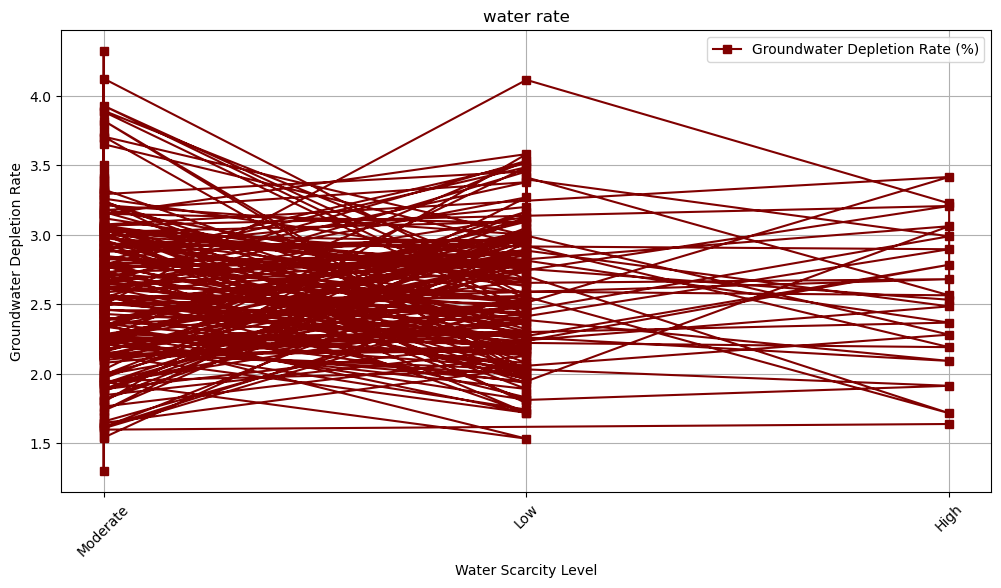

In [11]:
plt.figure(figsize=(12,6))
plt.plot(data['Water Scarcity Level'],data['Groundwater Depletion Rate (%)'],color='#800000',label='Groundwater Depletion Rate (%)',marker='s')
plt.xlabel('Water Scarcity Level')
plt.ylabel('Groundwater Depletion Rate')
plt.title('water rate')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# LABEL ENCODER

In [12]:
from sklearn.preprocessing import LabelEncoder
obj=LabelEncoder()


In [13]:
data["Country"]=obj.fit_transform(data["Country"])

In [14]:
data

,Country,Year,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (Annual Precipitation in mm),Groundwater Depletion Rate (%),Water Scarcity Level
0,0,2000,481.490000,235.431429,48.550000,20.844286,30.100000,1288.698571,3.255714,Moderate
1,0,2001,455.063000,299.551000,48.465000,26.943000,22.550000,1371.729000,3.120000,Moderate
2,0,2002,482.749231,340.124615,50.375385,29.042308,23.349231,1590.305385,2.733846,Moderate
3,0,2003,452.660000,326.756667,49.086667,30.476000,24.440000,1816.012667,2.708000,Moderate
4,0,2004,634.566000,230.346000,38.670000,36.670000,23.924000,815.998000,1.902000,Moderate
...,...,...,...,...,...,...,...,...,...,...
495,19,2020,418.097000,292.970000,47.448000,25.266000,27.538000,1510.662000,2.431000,Moderate
496,19,2021,572.094000,275.978000,46.195000,32.223000,26.720000,754.615000,2.628000,Moderate
497,19,2022,440.978000,292.039000,54.810000,30.918000,22.638000,2119.898000,2.871000,Moderate
498,19,2023,566.865000,261.197500,62.945000,25.207500,21.632500,1439.155000,1.597500,Moderate


# SETTING TARGET VALUE

In [15]:
x=data.drop(['Water Scarcity Level'],axis=1)
y=data['Water Scarcity Level']

In [16]:
y

0      Moderate
1      Moderate
2      Moderate
3      Moderate
4      Moderate
         ...   
495    Moderate
496    Moderate
497    Moderate
498    Moderate
499        High
Name: Water Scarcity Level, Length: 500, dtype: object

In [17]:
x

,Country,Year,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (Annual Precipitation in mm),Groundwater Depletion Rate (%)
0,0,2000,481.490000,235.431429,48.550000,20.844286,30.100000,1288.698571,3.255714
1,0,2001,455.063000,299.551000,48.465000,26.943000,22.550000,1371.729000,3.120000
2,0,2002,482.749231,340.124615,50.375385,29.042308,23.349231,1590.305385,2.733846
3,0,2003,452.660000,326.756667,49.086667,30.476000,24.440000,1816.012667,2.708000
4,0,2004,634.566000,230.346000,38.670000,36.670000,23.924000,815.998000,1.902000
...,...,...,...,...,...,...,...,...,...
495,19,2020,418.097000,292.970000,47.448000,25.266000,27.538000,1510.662000,2.431000
496,19,2021,572.094000,275.978000,46.195000,32.223000,26.720000,754.615000,2.628000
497,19,2022,440.978000,292.039000,54.810000,30.918000,22.638000,2119.898000,2.871000
498,19,2023,566.865000,261.197500,62.945000,25.207500,21.632500,1439.155000,1.597500


In [18]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)

In [19]:
ytrain

5      Moderate
116    Moderate
45     Moderate
16     Moderate
462    Moderate
         ...   
106    Moderate
270    Moderate
348    Moderate
435    Moderate
102    Moderate
Name: Water Scarcity Level, Length: 350, dtype: object

In [20]:
xtrain

,Country,Year,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (Annual Precipitation in mm),Groundwater Depletion Rate (%)
5,0,2005,458.077000,265.012000,59.834000,29.288000,22.649000,1826.293000,2.724000
116,4,2016,524.209333,289.594667,51.647333,32.768000,28.114667,1755.536667,3.066000
45,1,2020,484.798750,292.505000,48.473750,23.680000,27.546250,1549.618750,2.380000
16,0,2016,467.318095,322.053809,49.361905,28.402381,22.307619,1730.010000,2.642857
462,18,2012,583.028000,256.860000,55.234000,25.092000,28.568000,1908.753000,2.570000
...,...,...,...,...,...,...,...,...,...
106,4,2006,455.554546,296.594545,45.900909,23.290000,27.984545,1801.888182,2.977273
270,10,2020,211.816667,275.443333,63.690000,25.293333,20.760000,2151.440000,1.966667
348,13,2023,604.980000,268.150000,46.628000,34.144000,23.651000,1506.594000,2.485000
435,17,2010,559.448333,294.835000,49.486667,26.298333,17.395000,1073.235000,2.630000


# MODEL FITTING

## LogisticRegression

In [21]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [22]:
model.fit(xtrain,ytrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [23]:
poi=model.predict(xtest)
poi

array(['Moderate', 'Low', 'Moderate', 'Moderate', 'Low', 'Moderate',
       'Moderate', 'Moderate', 'Moderate', 'Low', 'Moderate', 'Moderate',
       'High', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate',
       'Low', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Low',
       'Low', 'Moderate', 'Moderate', 'Moderate', 'Low', 'Moderate',
       'Moderate', 'Low', 'Moderate', 'Moderate', 'Low', 'Moderate',
       'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate',
       'Moderate', 'High', 'Low', 'Moderate', 'Low', 'Moderate', 'Low',
       'Low', 'Moderate', 'Moderate', 'Low', 'Moderate', 'Moderate',
       'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate',
       'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Low',
       'Moderate', 'Low', 'Moderate', 'Moderate', 'Moderate', 'Low',
       'Moderate', 'High', 'Moderate', 'Low', 'Moderate', 'Moderate',
       'Moderate', 'Low', 'Moderate', 'Moderate', 'Moderate', 'Moderate',
       'Moder

In [24]:
Logistictrain=model.score(xtrain,ytrain)*100
Logistictrain

97.42857142857143

In [25]:
Logistictest=model.score(xtest,ytest)*100
Logistictest

92.0

# DecisionTreeClassifier

In [26]:
from sklearn.tree import DecisionTreeClassifier
model2=DecisionTreeClassifier()
model2.fit(xtrain,ytrain)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [27]:
DecisionTreetrain=model2.score(xtrain,ytrain)*100
DecisionTreetrain

100.0

In [28]:
DecisionTreetest=model2.score(xtest,ytest)*100
DecisionTreetest

94.66666666666667

# RandomForestClassifier

In [29]:
from sklearn.ensemble import RandomForestClassifier
model3=RandomForestClassifier(n_estimators=100)
model3.fit(xtrain,ytrain)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# AdaBoostClassifier

In [30]:
from sklearn.ensemble import AdaBoostClassifier
model4=AdaBoostClassifier(n_estimators=50)
model4.fit(xtrain,ytrain)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [31]:
AdaBoosttrain=model4.score(xtrain,ytrain)*100
AdaBoosttrain

100.0

In [32]:
AdaBoosttest=model4.score(xtest,ytest)*100
AdaBoosttest

96.66666666666667

# GradientBoostingClassifier

In [33]:
from sklearn.ensemble import GradientBoostingClassifier
model5=GradientBoostingClassifier(n_estimators=50)
model5.fit(xtrain,ytrain)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [34]:
GradientBoostingtrain=model5.score(xtrain,ytrain)*100
GradientBoostingtrain

100.0

In [35]:
GradientBoostingtest=model5.score(xtest,ytest)*100
GradientBoostingtest

95.33333333333334

# KNeighborsClassifier

In [36]:
from sklearn.neighbors import KNeighborsClassifier
model6=KNeighborsClassifier(n_neighbors=5)
model6.fit(xtrain,ytrain)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [37]:
KNeighborstrain=model6.score(xtrain,ytrain)*100
KNeighborstrain

87.14285714285714

In [38]:
KNeighborstest=model6.score(xtest,ytest)*100
KNeighborstest

74.66666666666667

# GaussianNB

In [39]:
from sklearn.naive_bayes import GaussianNB
model7=GaussianNB()

In [40]:
model7.fit(xtrain,ytrain)


,priors,None
,var_smoothing,1e-09


In [41]:
GaussianNBtrain=model7.score(xtrain,ytrain)*100
GaussianNBtrain

94.28571428571428

In [42]:
GaussianNBtest=model7.score(xtest,ytest)*100
GaussianNBtest

88.66666666666667

# PREDICTION

In [43]:
Country=(input("Enter the Country"))
Country=obj.transform([Country])

Enter the Country Argentina


In [44]:
Year=int(input("Enter the Year"))
Year

Enter the Year 2019


2019

In [45]:
Total_Water_Consumption=float(input("Enter the Total Water Consumption"))
Total_Water_Consumption

Enter the Total Water Consumption 74


74.0

In [46]:
Per_Capita_Water_Use=float(input("Enter the Per Capita Water Use"))
Per_Capita_Water_Use

Enter the Per Capita Water Use 54


54.0

In [47]:
Agricultural_Water_Use=float(input("Enter the Agricultural Water Use"))
Agricultural_Water_Use

Enter the Agricultural Water Use 24


24.0

In [48]:
Industrial_Water=float(input("Enter the Industrial Water"))
Industrial_Water

Enter the Industrial Water 48


48.0

In [49]:
Household_Water_use=float(input("Enter the Household Water Use"))
Household_Water_use

Enter the Household Water Use 72


72.0

In [50]:
Rainfall_Impact=float(input("Enter the  Rainfall Impact"))
Rainfall_Impact

Enter the  Rainfall Impact 10


10.0

In [51]:
Groundwater_Depletion_Rate =float(input("Enter the Groundwater Depletion Rate "))
Groundwater_Depletion_Rate

Enter the Groundwater Depletion Rate  78


78.0

In [52]:
print(model4.predict([[Country[0],Year,Total_Water_Consumption,Per_Capita_Water_Use,Agricultural_Water_Use,Industrial_Water,Household_Water_use,Rainfall_Impact,Groundwater_Depletion_Rate]]))

['Moderate']


# BUILD GRADIO INTERFACE

In [53]:
!pip3  install gradio

In [54]:
def fun(Country,Year,Total_Water_Consumption,Per_Capita_Water_Use,Agricultural_Water_Use,Industrial_Water,Household_Water_use,Rainfall_Impact,Groundwater_Depletion_Rate):
    Country=obj.fit_transform([Country])
    pred =model4.predict([[Country[0],Year,Total_Water_Consumption,Per_Capita_Water_Use,Agricultural_Water_Use,Industrial_Water,Household_Water_use,Rainfall_Impact,Groundwater_Depletion_Rate]])
    return pred
#fun(Country,Year,Total_Water_Consumption,Per_Capita_Water_Use,Agricultural_Water_Use,Industrial_Water,Household_Water_use,Rainfall_Impact,Groundwater_Depletion_Rate)

In [55]:
import gradio as gr

In [56]:
headline="WATER SCARCITY PREDICTION APP"
Countries=['Argentina', 'Australia', 'Brazil', 'Canada', 'China', 'France',
       'Germany', 'India', 'Indonesia', 'Italy', 'Japan', 'Mexico',
       'Russia', 'Saudi Arabia', 'South Africa', 'South Korea', 'Spain',
       'Turkey', 'UK', 'USA']
iface=gr.Interface(fn=fun,inputs=[
    gr.Dropdown(choices=Countries,label="Country"),
    gr.Textbox(label="Year"),
    gr.Textbox(label="Total_Water_Consumption"),
    gr.Textbox(label="Per_Capita_Water_Use"),
    gr.Textbox(label="Agricultural_Water_Use"),
    gr.Textbox(label="Industrial_Water"),
    gr.Textbox(label="Household_Water_use"),
    gr.Textbox(label="Rainfall_Impact"),
     gr.Textbox(label="Groundwater_Depletion_Rate")],
                   outputs=[gr.Textbox(label="Water Scarcity Level")],title=headline,css=".gradio-container{background-color:#98FB98;}")
iface.launch(share=True)

    

* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://eaa76e267eaebc484e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
